In [26]:
from dotenv import load_dotenv
load_dotenv()

True

In [27]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: list
    answer: str

graph_builder = StateGraph(AgentState)

In [28]:
from langchain_community.tools import TavilySearchResults

tavily_search_tool = TavilySearchResults(
    max_results=3,
    search_depth="advanced",
    include_answer=True,
    include_raw_content=True,
    include_images=True,
)

def web_search(state: AgentState) -> AgentState:
    query = state["query"]
    results = tavily_search_tool.invoke(query)
    return {"context": results}

In [29]:
from langsmith import Client
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

client = Client()
generate_prompt = client.pull_prompt("rlm/rag-prompt", dangerously_pull_public_prompt=True)

generate_llm = ChatOpenAI(model='gpt-4o')

def web_generate(state: AgentState) -> AgentState:
    context = state['context']
    query = state['query']
    rag_chain = generate_prompt | generate_llm | StrOutputParser()
    response = rag_chain.invoke({'question': query, 'context': context})
    return { 'answer': response }

In [30]:
basic_llm = ChatOpenAI(model="gpt-4o-mini")

def basic_generate(state: AgentState) -> AgentState:
    query = state['query']
    basic_llm_chain = basic_llm | StrOutputParser()
    llm_response = basic_llm_chain.invoke(query)
    return {'answer': llm_response}

In [31]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from typing import Literal

class Route(BaseModel):
    target: Literal['vector_store', 'llm', 'web_search'] = Field(
        description="The target for the query to answer"
    )

router_system_prompt = """
You are an expert at routing a user's question to 'vector_store', 'llm', or 'web_search'.
'vector_store' contains information about income tax up to December 2024.
if you think the question is simple enough use 'llm'
if you think you need to search the web to answer the question use 'web_search'
"""


router_prompt = ChatPromptTemplate.from_messages([
    ('system', router_system_prompt),
    ('user', '{query}')
])

router_llm = ChatOpenAI(model="gpt-4o-mini")
structured_router_llm = router_llm.with_structured_output(Route)

def router(state: AgentState) -> Literal['vector_store', 'llm', 'web_search']:
    query = state['query']
    router_chain = router_prompt | structured_router_llm
    route = router_chain.invoke({'query': query})
    return route.target

In [32]:
from income_tax_subgraph import graph as income_tax_subgraph

graph_builder.add_node('income_tax_agent', income_tax_subgraph)
graph_builder.add_node('web_search', web_search)
graph_builder.add_node('web_generate', web_generate)
graph_builder.add_node('basic_generate', basic_generate)

In [33]:
from langgraph.graph import START, END

graph_builder.add_conditional_edges(
    START,
    router,
    {
        'vector_store': 'income_tax_agent',
        'llm': 'basic_generate',
        'web_search': 'web_search'
    }
)

graph_builder.add_edge('web_search', 'web_generate')
graph_builder.add_edge('web_generate', END)
graph_builder.add_edge('basic_generate', END)
graph_builder.add_edge('income_tax_agent', END)

In [34]:
graph = graph_builder.compile()

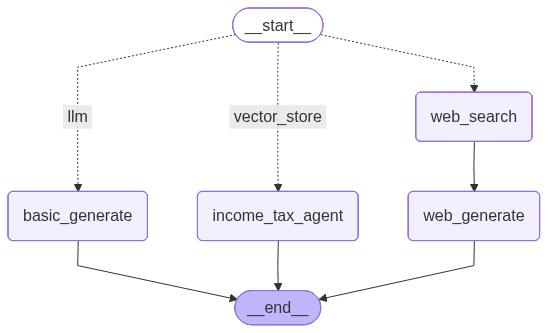

In [35]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [36]:
initial_state = {'query': '대한민국의 수도는 어디인가요?'}
graph.invoke(initial_state)

{'query': '대한민국의 수도는 어디인가요?', 'answer': '대한민국의 수도는 서울입니다.'}

In [37]:
initial_state = {'query': '연봉 5천만원인 거주자의 소득세는 얼마인가요?'}
graph.invoke(initial_state)

{'query': '연봉 5천만원인 거주자의 소득세는 얼마인가요?',
 'context': [Document(id='a5a56404-9342-4710-9bb5-323d3711f7d6', metadata={'source': '../documents/income_tax.md'}, page_content='10년 초과 20년 이하: 400만원 + 80만원 × (납입연수 - 10년)\n\n20년 초과: 1,200만원 + 120만원 × (납입연수 - 20년)\n\n② 직장근로자 초과관세환급금을 분배하여 지급받는 경우 세액의 계산 방법 등 필요한 사항은 대통령령으로 정한다. <대통령 2014. 12. 23.> <전문개정 2009. 12. 31.>\n\n제64조(부동산매매업자에 대한 세액 계산의 특례)\n\n1) 대통령령으로 정하는 부동산매매업(이하 “부동산매매업”이라 한다)을 영위하는 거주자가 이하 “부동산매매업자”라 한다)로서 종합소득세법에 제104조제1항제1호(본항을 포함한다) 및 제103조 또는 같은 조 제7항 각 호의 어느 하나에 해당하는 자산의 매매자익(이하 “주택등매매차익”이라 한다)이 있는 자의 종합소득 산출세액은 다음 각 호의 세액 중 많은 것으로 한다. <개정 2014. 12. 23., 2017. 12. 19., 2020. 12. 29.>\n\n1. 종합소득 산출세액\n\n다음 각 목에 따른 세액의 합계액 가. 주택등매매차익에 따른 세율을 적용하여 산출한 세액의 합계액 나. 종합소득세법 제55조에 따라 주택등매매차익에 대한 개별세액을 공제한 금액을 과세표준으로 하고 이에 제55조에 따른 세율을 적용하여 산출세액\n\n② 부동산매매업자에 대한 주택등매매차익의 계산과 그 밖에 종합소득 산출세액의 계산에 필요한 사항은 대통령령으로 정한다. <전문개정 2009. 12. 31.>\n\n제64조의2(주택임대소득에 대한 세액 계산의 특례)\n\n다음 각 호의 세액 중 하나를 선택하여 적용한다. 1. 제104조제1항제7호를 적용하지 아니하는 종합소득 세액 계산의 특례 

In [38]:
initial_state = {'query': '역삼 맛집을 추천해주세요'}
graph.invoke(initial_state)

{'query': '역삼 맛집을 추천해주세요',
 'context': [{'title': 'Ring Habell : 네이버 블로그',
   'url': 'https://blog.naver.com/pkj5456/224233504766?viewType=pc',
   'content': '| 서울 맛집  역삼역 맛집 추천 점심 역삼 직장인 맛집  프로파일 하벨   ・  2026. 3. 29. 19:41  URL 복사  이웃추가 본문 기타 기능 공유하기  신고하기  위치진대감 역삼점  역삼역 맛집 추천 점심\u200b  역삼 직장인 맛집\u200b  여행 인플루언서 @하벨  ---    역삼역 맛집 추천 점심 역삼 직장인 맛집  오랜만에 점심 먹으러 역삼역 맛집에 갔어요. 한우삼합으로 유명한 진대감인데요. 예전에 한번 맛보곤 다양한 조합에 반했던 곳이랍니다. 직접 구워주시고 삼합도 만들어주셔서 빠르고 편안하게 먹고 왔지 뭐에요:) 역근처에다가 음식도 빨리 나와서 역삼역 직장인 맛집으로도 손색 없었어요. 그럼 후기 남겨볼게요!  \u200b    위치 : 서울 강남 봉은사로30길 75 1층      진대감 역삼점 서울특별시 강남구 봉은사로30길 75 1층  ---  1. 역삼역 맛집 추천    \u200b  제가 방문한 진대감은 역삼역 6번 출구에서 걸어서 5분 거리에 위치해 있어요. 지도상으론 5분인데 실제로 걸어보니 거의 코앞이더라고요. 역에서 가까운 접근성이라 찾아가기 잘했다 싶었어요.  \u200b  \u200b    \u200b  또 건물 1층이라 금방 발견! 주차장이 있긴 하지만 협소하니 이왕이면 대중교통으로 가시는 걸 추천드릴게요.  \u200b  \u200b    \u200b  입구 앞에는 점심 한정 메뉴 리스트가 적힌 안내판이 세워져 있었어요. 흔히 고기라고 하면 회식이나 저녁 식사가 떠오르는데, 이 역삼역 직장인 맛집은 점심 메뉴도 잘 나오더라고요.  \u200b  \u200b    \u200b  한우꽃게된장찌개밥상, 꼬막비빔밥상 등 메인메뉴와 반찬이